In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import datasets
import json
import os

BASE_DS_DIR = '../../data/mlqa'

BASE_DS_NAME = 'base_dataset.csv'
QA_DS_NAME = 'qa_dataset.csv'
CONTEXTS_NAMES = 'contexts.csv'

DS_LANG_NAMES = {
    'ar': 'test-context-ar-question-ar.json',
    'de': 'test-context-de-question-de.json',
    'es': 'test-context-es-question-es.json',
    'hi': 'test-context-hi-question-hi.json',
    'vi': 'test-context-vi-question-vi.json',
    'zh': 'test-context-zh-question-zh.json'
}

REPO_NAME = "facebook/mlqa"

In [2]:
def print_df_stat(df):
    print("===Статистика по исходному датасету===")
    print("Количество строк в датасете: ", df.shape[0])
    print("Количество уникальных context-текстов: ", len(df['context'].unique()))
    print("Количество уникальных question-текстов: ", len(df['question'].unique()))
    print("Количество уникальных answer-текстов: ", len(df['answer'].unique()))

(5020, 3)
(4431, 1)


100%|██████████| 5020/5020 [00:00<00:00, 65621.79it/s]

(5020, 3) 5020
(5020, 3)
test-context-ar-question-ar.json
===Статистика по исходному датасету===
Количество строк в датасете:  5022
Количество уникальных context-текстов:  4431
Количество уникальных question-текстов:  5020
Количество уникальных answer-текстов:  4718


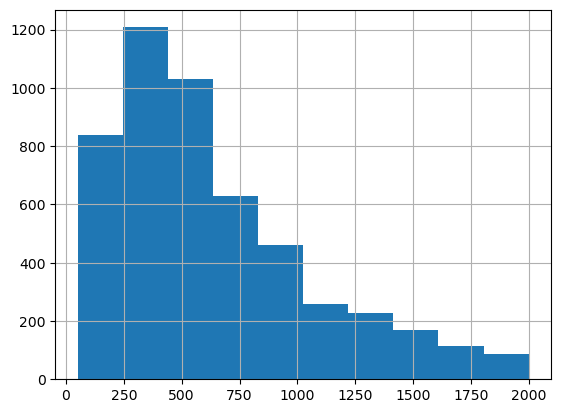

(4217, 3)
(3846, 1)


100%|██████████| 4217/4217 [00:00<00:00, 67729.85it/s]


(4217, 3) 4217
(4217, 3)
test-context-de-question-de.json
===Статистика по исходному датасету===
Количество строк в датасете:  4221
Количество уникальных context-текстов:  3846
Количество уникальных question-текстов:  4217
Количество уникальных answer-текстов:  3833


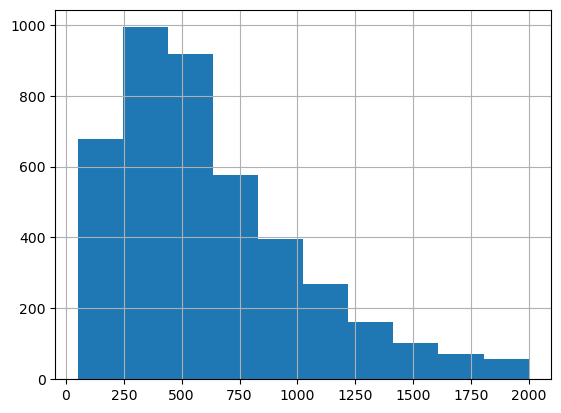

(5193, 3)
(4720, 1)


100%|██████████| 5193/5193 [00:00<00:00, 59945.01it/s]

(5193, 3) 5193
(5193, 3)
test-context-es-question-es.json
===Статистика по исходному датасету===
Количество строк в датасете:  5195
Количество уникальных context-текстов:  4720
Количество уникальных question-текстов:  5193
Количество уникальных answer-текстов:  4915


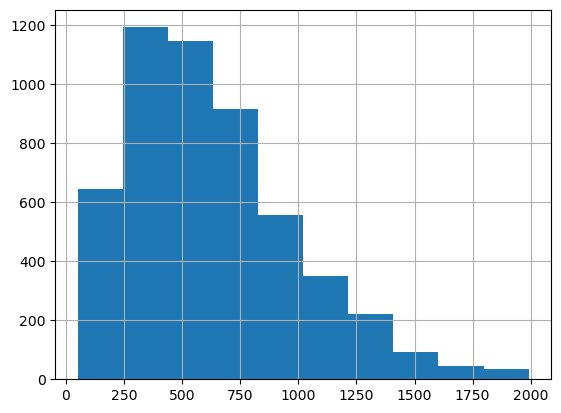

(4598, 3)
(3903, 1)


100%|██████████| 4598/4598 [00:00<00:00, 69372.23it/s]

(4598, 3) 4598
(4598, 3)
test-context-hi-question-hi.json
===Статистика по исходному датасету===
Количество строк в датасете:  4600
Количество уникальных context-текстов:  3903
Количество уникальных question-текстов:  4598
Количество уникальных answer-текстов:  4247


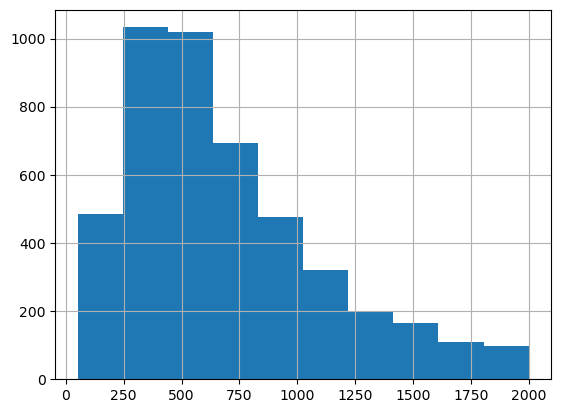

(4878, 3)
(4340, 1)


100%|██████████| 4878/4878 [00:00<00:00, 63908.36it/s]

(4878, 3) 4878
(4878, 3)
test-context-vi-question-vi.json
===Статистика по исходному датасету===
Количество строк в датасете:  4878
Количество уникальных context-текстов:  4340
Количество уникальных question-текстов:  4878
Количество уникальных answer-текстов:  4503


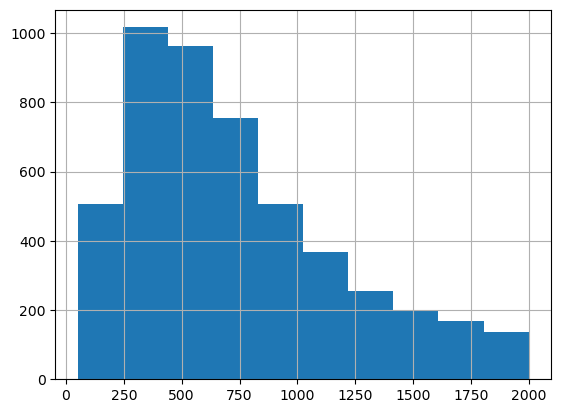

(5131, 3)
(4542, 1)


100%|██████████| 5131/5131 [00:00<00:00, 60911.06it/s]


(5131, 3) 5131
(5131, 3)
test-context-zh-question-zh.json
===Статистика по исходному датасету===
Количество строк в датасете:  5132
Количество уникальных context-текстов:  4542
Количество уникальных question-текстов:  5131
Количество уникальных answer-текстов:  4784


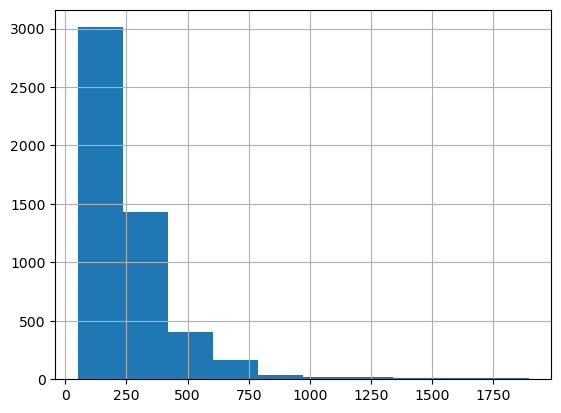

In [3]:
for lang, ds_name in DS_LANG_NAMES.items():
    with open(ds_name, 'r', encoding='utf-8') as fd:
        ds = json.loads(fd.read())

    questions = []
    answers = []
    contexts = []
    for i in range(len(ds['data'])):
        for j in range(len(ds['data'][i]['paragraphs'])):
            for k in range(len(ds['data'][i]['paragraphs'][j]['qas'])):
                contexts.append(ds['data'][i]['paragraphs'][j]['context'])
                questions.append(ds['data'][i]['paragraphs'][j]['qas'][k]['question'])
                answers.append(ds['data'][i]['paragraphs'][j]['qas'][k]['answers'][0]['text'])

    df = pd.DataFrame({'question': questions, 'answer': answers, 'context': contexts})
    os.mkdir(f"{BASE_DS_DIR}/{lang}/")
    df.to_csv(f"{BASE_DS_DIR}/{lang}/{BASE_DS_NAME}")

    cuted_df = df[df['context'].str.len() <= 2000].reset_index(drop=True)
    
    filtered_df = cuted_df.drop_duplicates(subset=['question']).reset_index(drop=True)
    print(filtered_df.shape)

    contexts_dataset = cuted_df['context'].unique().tolist()
    contexts_df = pd.DataFrame(contexts_dataset, columns=['context'])
    contexts_df.to_csv(f"{BASE_DS_DIR}/{lang}/{CONTEXTS_NAMES}", index=False)
    print(contexts_df.shape)

    qa_dataset = []
    for i in tqdm(range(filtered_df.shape[0])):
        if len(filtered_df['answer']):
            item = [ filtered_df['question'][i], filtered_df['answer'][i], contexts_dataset.index(filtered_df['context'][i])]
            qa_dataset.append(item)
    print(filtered_df.shape, len(qa_dataset))

    qa_df = pd.DataFrame(qa_dataset, columns=['question', 'answer', 'relevant_context_id'])
    qa_df.to_csv(f"{BASE_DS_DIR}/{lang}/{QA_DS_NAME}", index=False)
    print(qa_df.shape)
    
    print(f"{ds_name}")
    print_df_stat(cuted_df)

    plt.hist(list(map(len, cuted_df['context'].tolist())))
    plt.grid()
    plt.show()
